In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# DataSet Selection

## here we are taking the data credit_card_transactions

##  2 Data Loading

In [7]:
df=pd.read_csv("credit_card_transactions.csv")
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,28705.0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,NaN
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,83236.0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0,NaN
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0,22844.0


## 3. Data Observation


- Dataset contains ___ rows and ___ columns  
- Includes numerical and categorical features  
- Target variable: (e.g., fraud / default / churn)  
- Data types include int, float, and object  

In [9]:
#Shape of the data set
df.shape

(1296675, 24)

In [12]:
#Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 24 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

In [13]:
#Statistical summary
df.describe()

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode
count,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.100702e+06
mean,6.483370e+05,4.171920e+17,7.035104e+01,4.880067e+04,3.853762e+01,-9.022634e+01,8.882444e+04,1.349244e+09,3.853734e+01,-9.022646e+01,5.788652e-03,4.682575e+04
std,3.743180e+05,1.308806e+18,1.603160e+02,2.689322e+04,5.075808e+00,1.375908e+01,3.019564e+05,1.284128e+07,5.109788e+00,1.377109e+01,7.586269e-02,2.583400e+04
min,0.000000e+00,6.041621e+10,1.000000e+00,1.257000e+03,2.002710e+01,-1.656723e+02,2.300000e+01,1.325376e+09,1.902779e+01,-1.666712e+02,0.000000e+00,1.001000e+03
25%,3.241685e+05,1.800429e+14,9.650000e+00,2.623700e+04,3.462050e+01,-9.679800e+01,7.430000e+02,1.338751e+09,3.473357e+01,-9.689728e+01,0.000000e+00,2.511400e+04
50%,6.483370e+05,3.521417e+15,4.752000e+01,4.817400e+04,3.935430e+01,-8.747690e+01,2.456000e+03,1.349250e+09,3.936568e+01,-8.743839e+01,0.000000e+00,4.586000e+04
75%,9.725055e+05,4.642255e+15,8.314000e+01,7.204200e+04,4.194040e+01,-8.015800e+01,2.032800e+04,1.359385e+09,4.195716e+01,-8.023680e+01,0.000000e+00,6.831900e+04
max,1.296674e+06,4.992346e+18,2.894890e+04,9.978300e+04,6.669330e+01,-6.795030e+01,2.906700e+06,1.371817e+09,6.751027e+01,-6.695090e+01,1.000000e+00,9.940300e+04


In [15]:
#Column name
df.columns

Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud', 'merch_zipcode'],
      dtype='object')

## 4.Data Cleaning & Prepapration

In [16]:
df.shape

(1296675, 24)

### Renaming the columns with lowercase

In [18]:
df.columns=df.columns.str.lower().str.replace(" ","_")
df.columns

Index(['unnamed:_0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud', 'merch_zipcode'],
      dtype='object')

### finding the missing values

In [21]:
df.isnull().sum()

unnamed:_0                    0
trans_date_trans_time         0
cc_num                        0
merchant                      0
category                      0
amt                           0
first                         0
last                          0
gender                        0
street                        0
city                          0
state                         0
zip                           0
lat                           0
long                          0
city_pop                      0
job                           0
dob                           0
trans_num                     0
unix_time                     0
merch_lat                     0
merch_long                    0
is_fraud                      0
merch_zipcode            195973
dtype: int64

### here we are doing handling the missing values

- Most columns do not contain missing values.
- The column `merch_zipcode` contains a large number of missing values (~195,973).
- Since the proportion of missing data is very high and the feature is not critical, the column was dropped from the dataset.

df.drop(columns=['merch_zipcode'],inplace=True)

In [30]:
df.duplicated().sum()

np.int64(0)

### 5. Outlier Detection & Treatment
## Observation
The dataset is (balanced / imbalanced). Appropriate techniques may be required if imbalance is high.

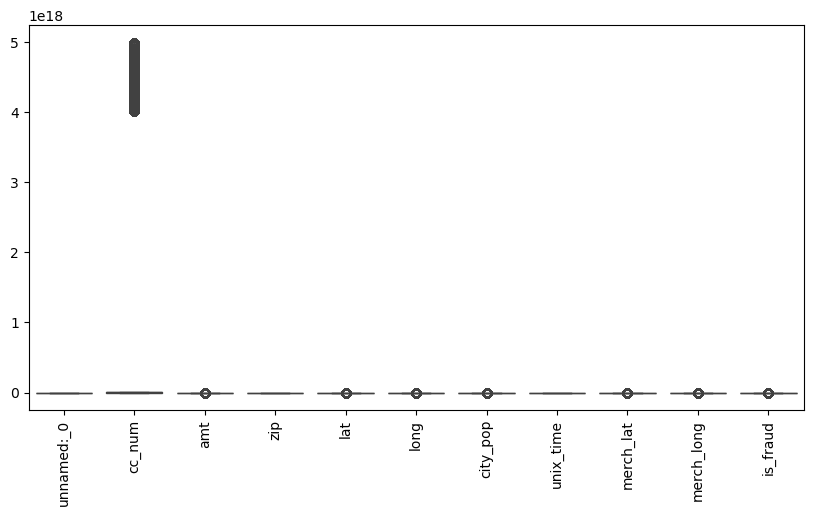

In [35]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df.select_dtypes(include=np.number))
plt.xticks(rotation=90)
plt.show()

In [38]:
Q1 = df['amt'].quantile(0.25)
Q3 = df['amt'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

In [43]:
df = df[(df['amt'] >= lower) & (df['amt'] <= upper)]

### 6. Check Imbalance (Target Variable)


Target Distribution:
 is_fraud
0    1227584
1       1801
Name: count, dtype: int64


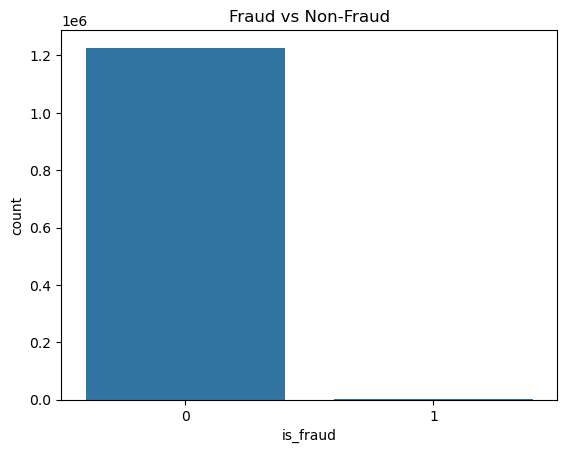

In [49]:
print("\nTarget Distribution:\n", df['is_fraud'].value_counts())

plt.figure()
sns.countplot(x='is_fraud', data=df)
plt.title("Fraud vs Non-Fraud")
plt.show()

### 7.Exploratory Data Analysis (EDA)

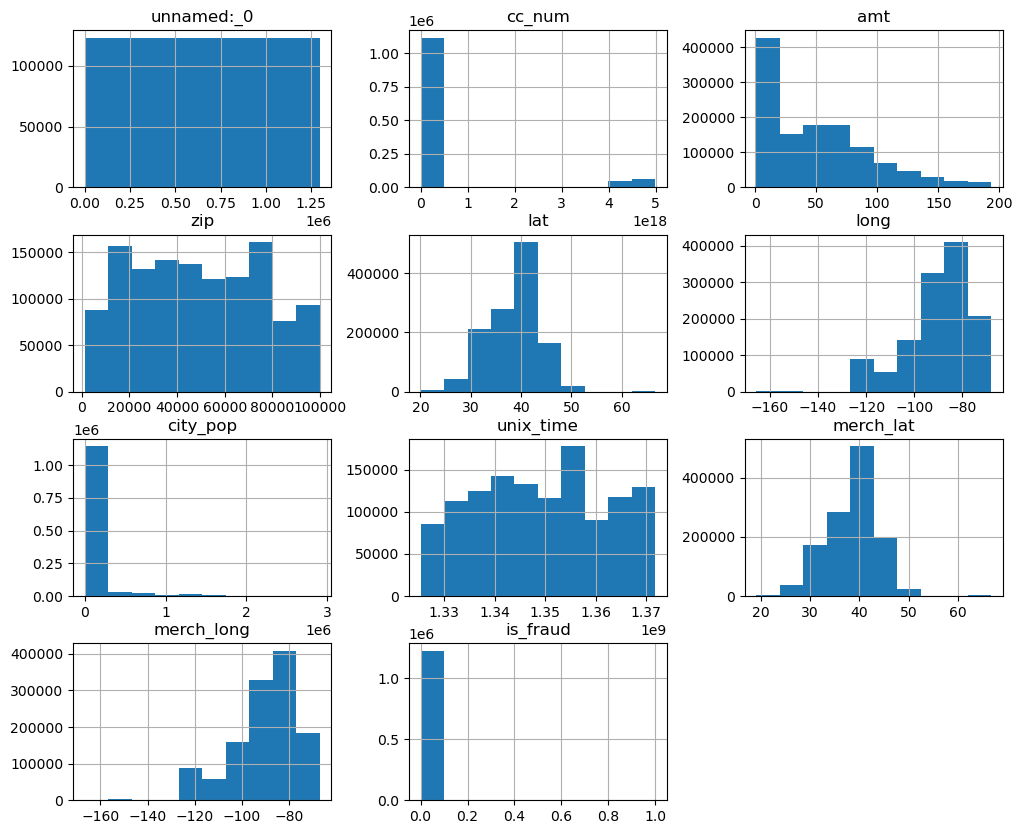

In [50]:
df.hist(figsize=(12,10))
plt.show()

<Axes: xlabel='is_fraud', ylabel='count'>

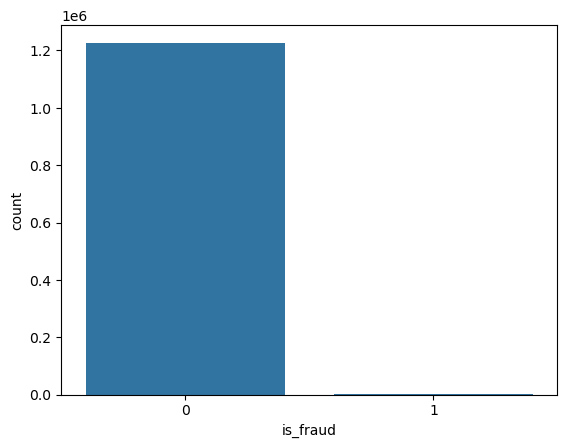

In [54]:
sns.countplot(x='is_fraud',data=df)

## Bivariate Analysis

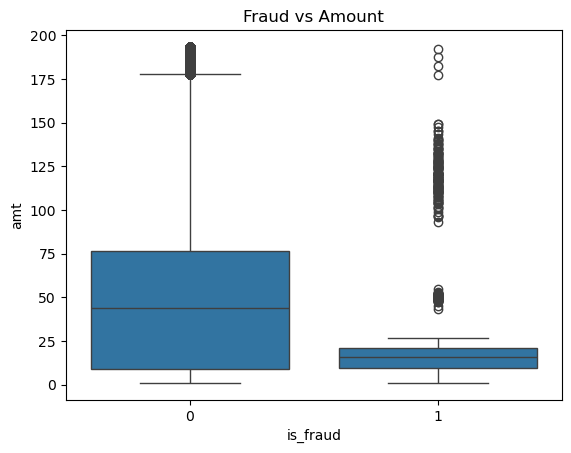

In [60]:
plt.figure()
sns.boxplot(x='is_fraud', y='amt', data=df)
plt.title("Fraud vs Amount")
plt.show()

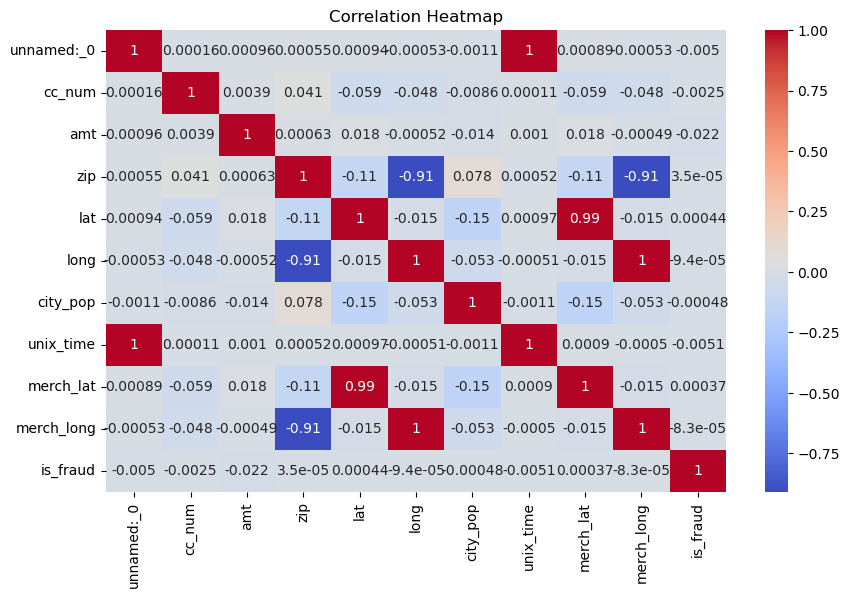

In [62]:
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

### 8. Pivot Tables

In [65]:
pivot = pd.pivot_table(df,
                       values='amt',
                       index='category',
                       columns='is_fraud',
                       aggfunc='mean')

pivot

is_fraud,0,1
category,,
entertainment,54.268932,NaN
food_dining,47.320388,120.076954
gas_transport,63.675782,12.288204
grocery_net,53.792817,12.162836
grocery_pos,102.924260,NaN
health_fitness,50.340690,20.248421
home,54.194474,184.812500
kids_pets,53.585837,18.121674
misc_net,34.286280,NaN


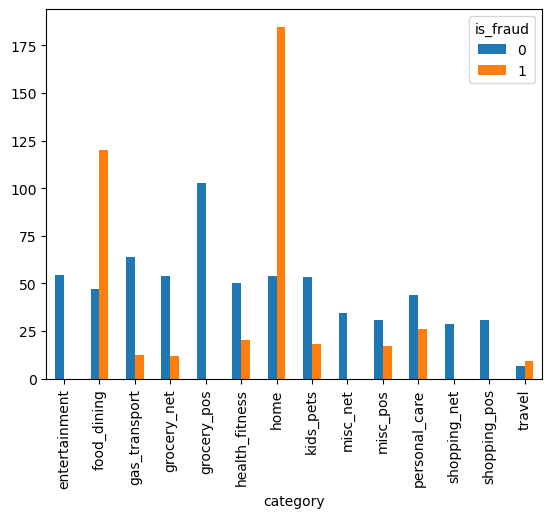

In [66]:
pivot.plot(kind='bar')
plt.show()

### 9.Final Insights

- Feature ___ has strong correlation with target  
- Customers with ___ tend to ___  
- Outliers were found in ___ and treated using IQR  
- Dataset is (balanced / imbalanced)  
- Missing values handled using median/mode  